# Job training and subsequent earnings
**Question:** How does enrolling in Job Training Partnership Act (JTPA) services affect subsequent earnings.

## 1. Research question and target population

The question we are seeking to answer is: "How does enrolling in JTPA services impact total earnings?"  We will define the following experimental variables.

- **Unit:** an adult in the JTPA research sample.
- **Outcome `Y`:** total earnings in the 30 months following random assignment.
- **Assignment `Z`:** randomized offer of JTPA services.
- **Treatment `T`:** actual enrollment in JTPA services.

## 2. Data and preprocessing

In [1]:
from pathlib import Path
from hashlib import sha256
from importlib.metadata import version
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter, PercentFormatter
import statsmodels.formula.api as smf
from linearmodels.iv import IV2SLS
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (9, 5), "figure.dpi": 110})
pd.set_option("display.max_columns", 25)

In [2]:
# Locate the project from either its root or the notebooks directory.
PROJECT_ROOT = next(
    (
        path
        for path in (Path.cwd(), *Path.cwd().parents)
        if (path / "data/raw/jtpa.raw").is_file()
        and (path / "docs/data_dictionary.csv").is_file()
    ),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Start Jupyter inside job-training-causal-inference.")
RAW_DATA = PROJECT_ROOT / "data/raw/jtpa.raw"
FIGURES_DIR = PROJECT_ROOT / "outputs/figures"
TABLES_DIR = PROJECT_ROOT / "outputs/tables"
PROCESSED_DIR = PROJECT_ROOT / "data/processed"
for directory in (FIGURES_DIR, TABLES_DIR, PROCESSED_DIR):
    directory.mkdir(parents=True, exist_ok=True)
Y, T, Z = "earnings_30mo", "enrolled", "offer"
print(f"Project: {PROJECT_ROOT}\nPython: {sys.version.split()[0]}")
print(
    " | ".join(
        f"{name} {version(name)}"
        for name in [
            "numpy",
            "pandas",
            "matplotlib",
            "seaborn",
            "statsmodels",
            "linearmodels",
        ]
    )
)

Project: /Users/drewmathieson/Projects/job-training-causal-inference
Python: 3.14.3
numpy 2.5.2 | pandas 3.0.5 | matplotlib 3.11.1 | seaborn 0.13.2 | statsmodels 0.14.6 | linearmodels 7.0


### Source and data checks

Source: [MIT's Angrist Data Archive](https://economics.mit.edu/people/faculty/josh-angrist/angrist-data-archive).

In [3]:
dictionary = pd.read_csv(PROJECT_ROOT / "docs/data_dictionary.csv")
columns = dictionary.sort_values("source_column")["name"].tolist()
raw = pd.read_csv(RAW_DATA, sep=r"\s+", header=None, names=columns)
assert raw.shape == (11_204, len(columns)), "Unexpected source shape."
assert raw["person_id"].is_unique, "Expected one row per person."
assert raw[[Z, T, "male"]].isin([0, 1]).all().all()
assert raw[Y].ge(0).all()
df = raw.copy()
print(f"Loaded {len(raw):,} people and {raw.shape[1]} source columns.")
display(raw.head())

Loaded 11,204 people and 19 source columns.


,person_id,earnings_30mo,offer,enrolled,male,hsorged,black,hispanic,married,wkless13,afdc,age2225,age2629,age3035,age3644,age4554,class_tr,ojt_jsa,f2sms
0,300001,1353,1,1,0,1.0,1,0,0.000000,1.0,0,0,0,0,0,1,0,0,0
1,300002,4984,1,1,0,1.0,0,0,0.000000,0.0,0,1,0,0,0,0,0,0,0
2,300006,27707,1,0,0,1.0,0,1,1.000000,1.0,0,0,0,1,0,0,1,0,0
3,300008,31860,1,0,0,1.0,0,0,0.000000,0.0,0,0,0,1,0,0,0,1,0
4,300010,26615,0,0,0,0.0,0,0,0.211161,0.0,0,1,0,0,0,0,0,1,0


In [4]:
display(dictionary)
display(
    pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "unique_values": df.nunique(),
        }
    )
)

,source_column,name,description,role
0,1,person_id,Record identifier; not a covariate.,identifier
1,2,earnings_30mo,Total earnings in dollars over 30 months follo...,outcome
2,3,offer,Random assignment to an offer of JTPA services...,instrument / assignment
3,4,enrolled,Actual enrollment in JTPA services: 1 enrolled...,treatment
4,5,male,"Source sex coding: 1 male, 0 female.",baseline characteristic
5,6,hsorged,High-school diploma or GED indicator; fraction...,baseline characteristic
6,7,black,Source indicator for Black participants.,baseline characteristic
7,8,hispanic,Source indicator for Hispanic participants.,baseline characteristic
8,9,married,Marital-status indicator; fractional entries o...,baseline characteristic
9,10,wkless13,Prior-employment variable. Verify the threshol...,baseline characteristic; review coding


,dtype,missing,unique_values
person_id,int64,0,11204
earnings_30mo,int64,0,8321
offer,int64,0,2
enrolled,int64,0,2
male,int64,0,2
hsorged,float64,0,4
black,int64,0,2
hispanic,int64,0,2
married,float64,0,4
wkless13,float64,0,4


### Research why married, hsorged, and wkless13 have 4 values

By reading the associated paper, we discover that the data currently treats missing values for these three features by imputing a sex-specific fractional value.  Marital status, for example, is using the proportion of people within that category that are married, split by men vs women.  Since missing marital status, prior education or prior employment may not be independent across our sample, I will instead add an unknown category so we don't unintentionally bias our data. This gives the missing group its own intercept, independent of the yes/no groups. Ultimately, either decision likely will not affect our model or standard errors much, but in my opinion treating missing data as unknown is more honest and interpretable. I do not recommend simply dropping the population with missing values as it will decrease our statistical strength of our analysis, and I do not know if missingness is independent of our outcome, which means dropping could lead to bias.

Note that treating missing as unknown is not without its own potential to increase bias: [Missing-indicator methods and their limitations](https://pmc.ncbi.nlm.nih.gov/articles/PMC3414599/).  However, in this instance, data was collected before random assignment, so missingness is independent of exposure.  

#### Reclassify missing values as missing.

The preprocessing below applies the Unknown-category rule to marriage status (married), prior employment (wkless13), and prior education (hsorged).

In [5]:
def binary_with_unknown(series, labels):
    """Keep source 0/1; represent fractional or missing entries as Unknown."""
    unknown = series.isna() | (series.gt(0) & series.lt(1))
    if not (series.isin([0, 1]) | unknown).all():
        raise ValueError(f"Unexpected codes in {series.name}; inspect before recoding.")
    values = series.map({0: labels[0], 1: labels[1]}).fillna("Unknown")
    return pd.Categorical(values, categories=[*labels, "Unknown"])


# Start from raw so this cell is safe to rerun. No redundant unknown indicators.
df = raw.copy()
status_specs = {
    "married": ("married", ["Not married", "Married"]),
    "hsorged": ("hsorged", ["No diploma/GED", "Diploma/GED"]),
    "prior_employment_status": (
        "wkless13",
        [
            "Worked 13 weeks or more in prior year",
            "Worked less than 13 weeks in prior year",
        ],
    ),
}
for target, (source, labels) in status_specs.items():
    df[target] = binary_with_unknown(raw[source], labels)

unknown_status_summary = pd.DataFrame(
    [
        {
            "Variable": name,
            "Unknown": int(df[name].eq("Unknown").sum()),
            "Unknown share": df[name].eq("Unknown").mean(),
        }
        for name in status_specs
    ]
)
display(
    unknown_status_summary.style.hide(axis="index").format(
        {"Unknown": "{:,.0f}", "Unknown share": "{:.2%}"}
    )
)

# Use the same category coding in balance plots and in the regressions.
analysis_covariates = [
    "prior_employment_status" if name == "wkless13" else name
    for name in columns
    if name not in ["person_id", Y, T, Z]
]

Variable,Unknown,Unknown share
married,764,6.82%
hsorged,695,6.20%
prior_employment_status,"1,178",10.51%


## 3. Earnings distribution and assignment balance

I'll now inspect the earnings distribution using both linear and log scales.  Notice the sizable portion of 0 earners.

Zero earnings: 1,332 of 11,204 people (11.9%)


,30-month earnings ($)
count,11204.00
mean,15815.29
std,16767.05
min,0.00
25%,1929.75
50%,11010.00
75%,24798.25
max,155760.00


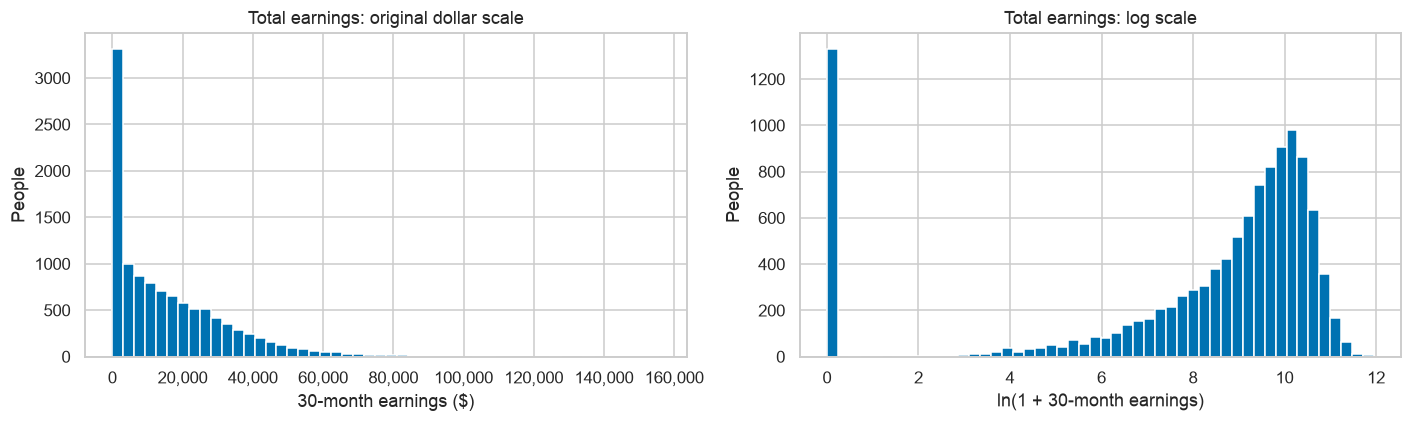

In [6]:
print(
    f"Zero earnings: {df[Y].eq(0).sum():,} of {len(df):,} people ({df[Y].eq(0).mean():.1%})"
)
display(df[Y].describe().to_frame("30-month earnings ($)").round(2))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df[Y], bins=50, color="#0072B2")
axes[0].set(
    title="Total earnings: original dollar scale",
    xlabel="30-month earnings ($)",
    ylabel="People",
)
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda value, _: f"{value:,.0f}"))
axes[1].hist(np.log1p(df[Y]), bins=50, color="#0072B2")
axes[1].set(
    title="Total earnings: log scale",
    xlabel="ln(1 + 30-month earnings)",
    ylabel="People",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "earnings_distribution.png", bbox_inches="tight")
plt.show()
# Both plots include zero earners; all regression outcomes remain in dollars.

Our distribution is right-skewed due to a very large number of 0 earners.  This poses significant downside for using a log transformation. We have to either drop the 0 earners, which make up a huge portion of our sample and are essential to answering the causal question. Or we have to transform the log by adding some constant C.  This arbitrary choice of C will cause our estimate to depend on C and be less interpretable, and we additionally lose the property of the log-estimate being a percentage increase in wages.

For these reasons, we continue by using the dollar-scale earnings, which leads to an interpretable estimate and cleaner handling of 0 earners.  The usual argument against dollar-scale is large outlier effects due to skewed distributions, but our large sample size and use of robust standard errors will mitigate those issues.  

### Assignment balance

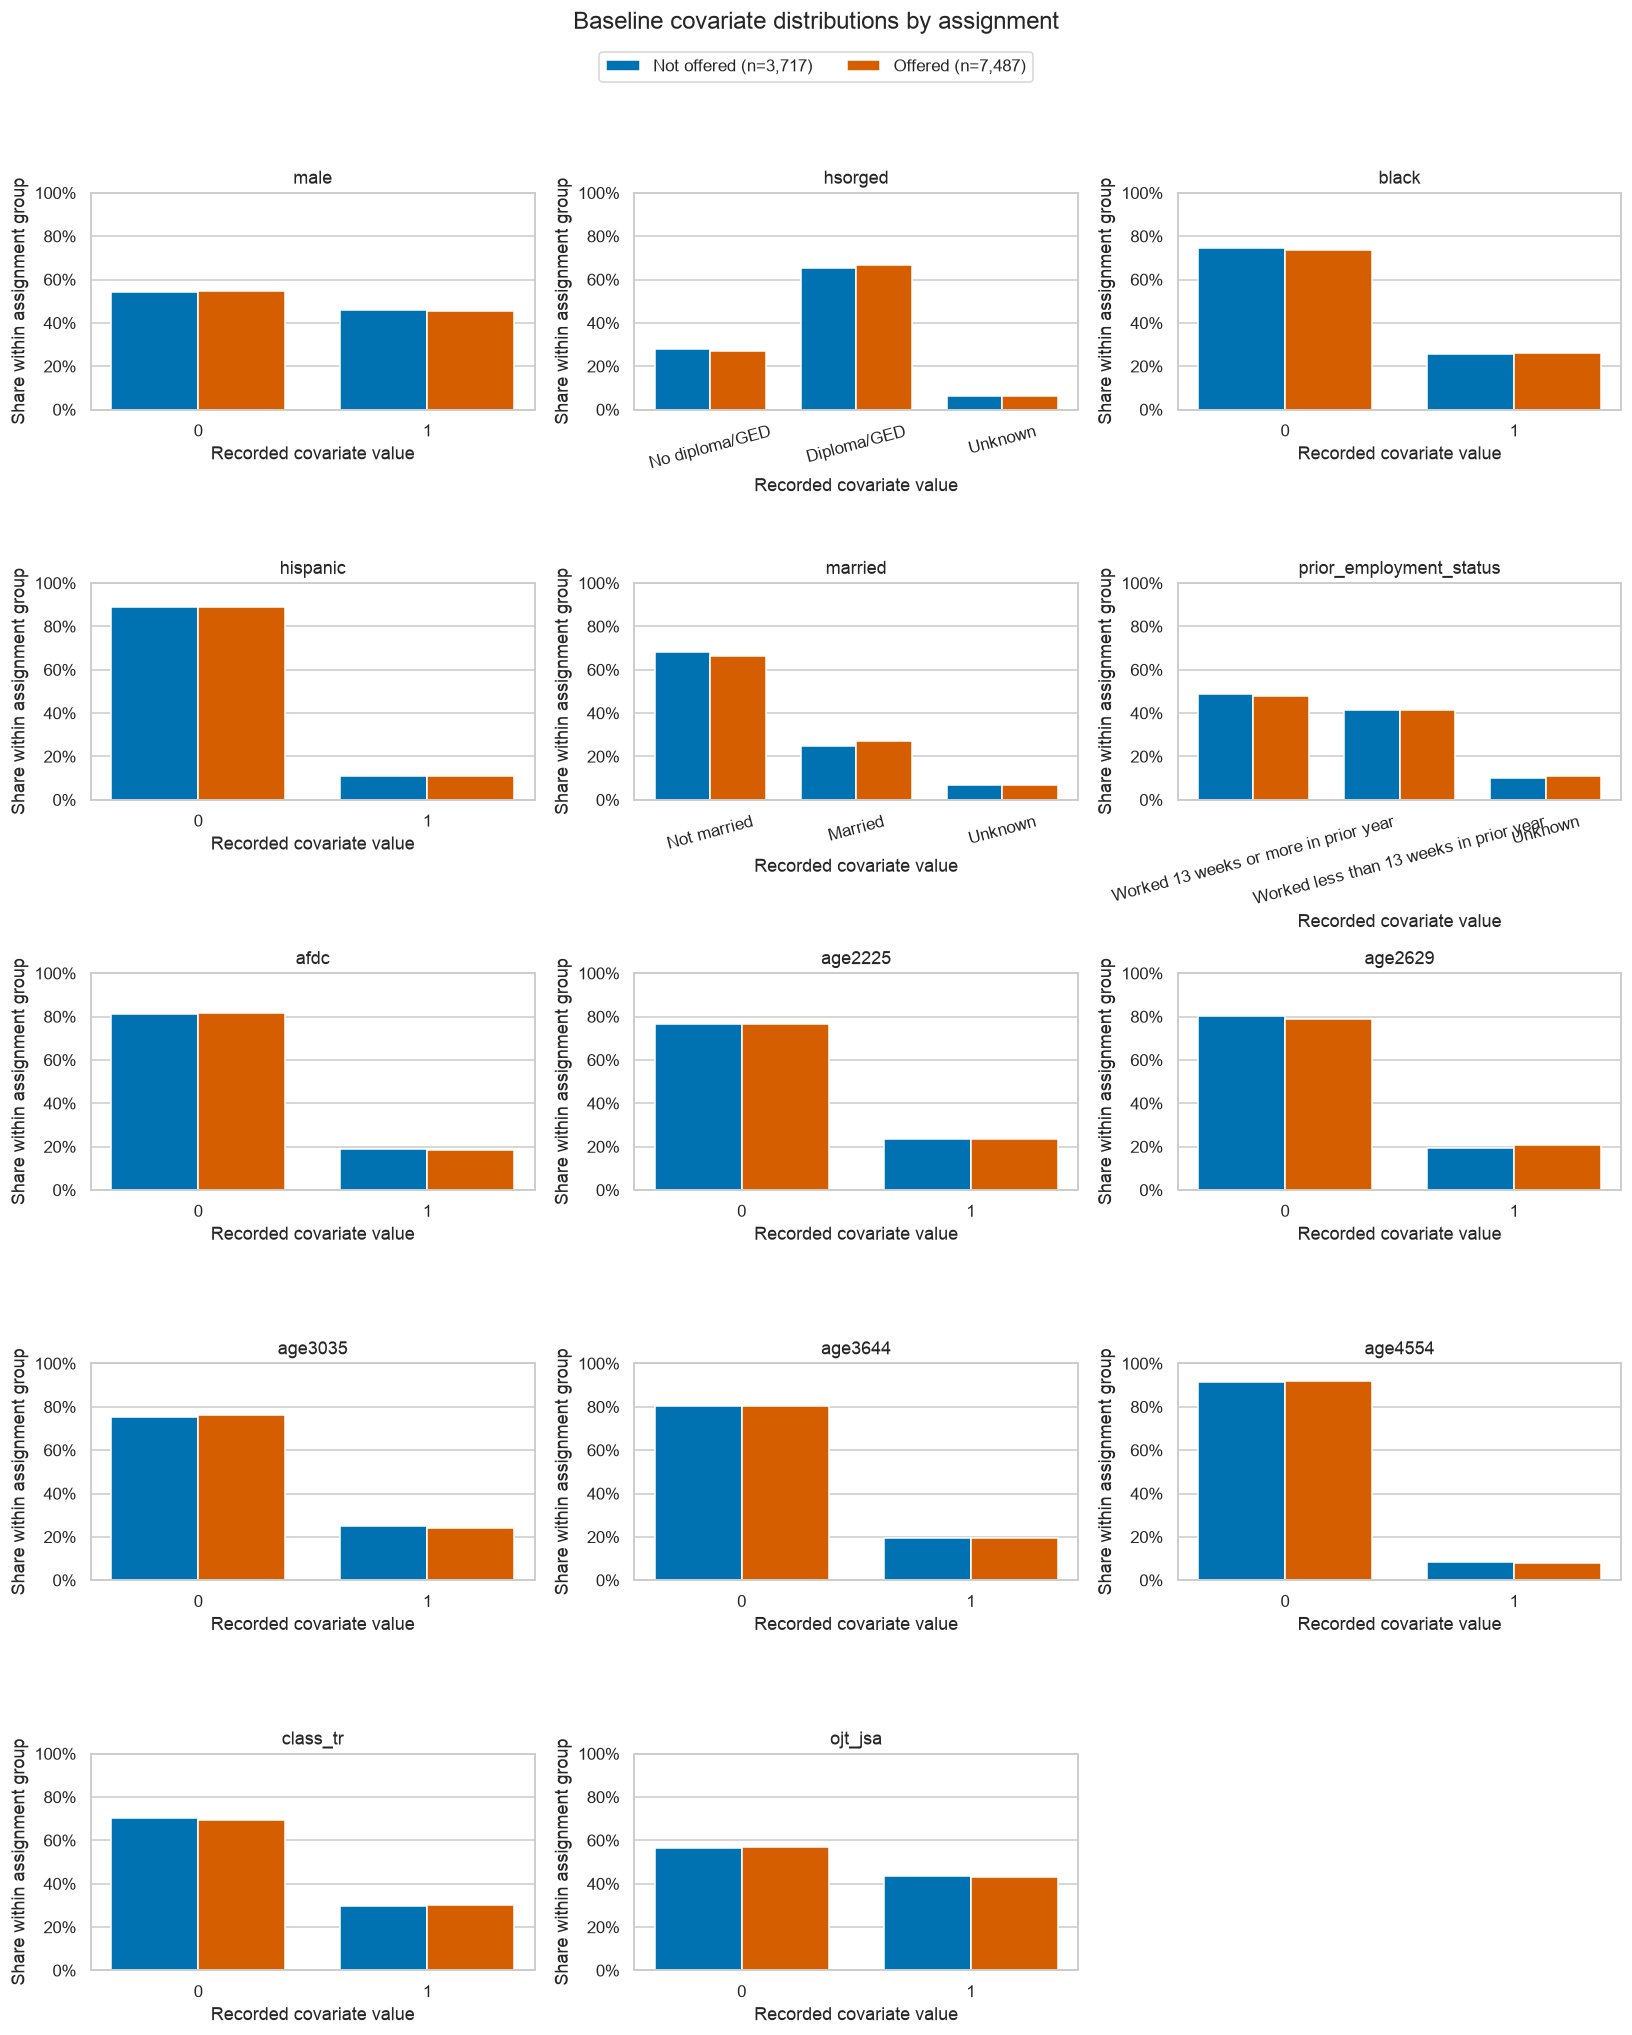

In [16]:
def plot_assignment_balance(data, variables, title, filename):
    """Compare distributions within assignment groups, not raw group sizes."""
    counts = data[Z].value_counts().reindex([0, 1], fill_value=0)
    labels = [
        f"{'Not offered' if z == 0 else 'Offered'} (n={counts[z]:,})" for z in [0, 1]
    ]
    nrows = (len(variables) + 2) // 3
    fig, axes = plt.subplots(nrows, 3, figsize=(15, 3.5 * nrows + 1), squeeze=False)
    for ax, name in zip(axes.flat, variables):
        shares = pd.crosstab(data[name], data[Z]).reindex(columns=[0, 1], fill_value=0)
        if data[name].isna().any():
            shares.loc["Missing"] = (
                data.loc[data[name].isna(), Z]
                .value_counts()
                .reindex([0, 1], fill_value=0)
            )
        shares = shares.div(counts, axis="columns") * 100
        positions = np.arange(len(shares))
        for z, offset, color in [(0, -0.19, "#0072B2"), (1, 0.19, "#D55E00")]:
            ax.bar(
                positions + offset, shares[z], width=0.38, color=color, label=labels[z]
            )
        ax.set(
            title=name,
            xlabel="Recorded covariate value",
            ylabel="Share within assignment group",
            ylim=(0, 100),
        )
        ax.set_xticks(
            positions, shares.index.astype(str), rotation=15 if len(shares) > 2 else 0
        )
        ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
        ax.grid(axis="x", visible=False)
    for ax in axes.flat[len(variables) :]:
        ax.set_visible(False)
    fig.legend(
        *axes.flat[0].get_legend_handles_labels(),
        loc="upper center",
        bbox_to_anchor=(0.5, 1 - 0.32 / fig.get_figheight()),
        ncol=2,
    )
    fig.suptitle(title, y=1 - 0.02 / fig.get_figheight(), fontsize=16)
    fig.tight_layout(rect=(0, 0, 1, 1 - 0.9 / fig.get_figheight()))
    fig.savefig(FIGURES_DIR / filename, bbox_inches="tight")
    plt.show()


# Service-strategy recommendations and AFDC are recorded at intake, so they are
# baseline covariates. Only the survey-source flag is determined after assignment.
survey_source = ["f2sms"]
plot_assignment_balance(
    df,
    [x for x in analysis_covariates if x not in survey_source],
    "Baseline covariate distributions by assignment",
    "balance_baseline.png",
)

### Results consistent with random assignment
These plots show balance consistent with randomization across our different covariates, as described by the study. While this result is expected, its always useful to check to ensure randomness was actually achieved.

## 4. DAG and proposed controls

I'll now draw a DAG which will make it easier to determine causal paths, potential confounders and which controls to use to improve the regression.  Unobserved features are lighter gray than observed features.

The arrows are proposed mechanisms, not conclusions established with any analytical or statistical significance.  Because these are proposed mechanisms, its best practice to include a short justification for each arrow drawn.  Causal paths from enrollment to income are drawn in green, while potential confounding paths are drawn in purple.

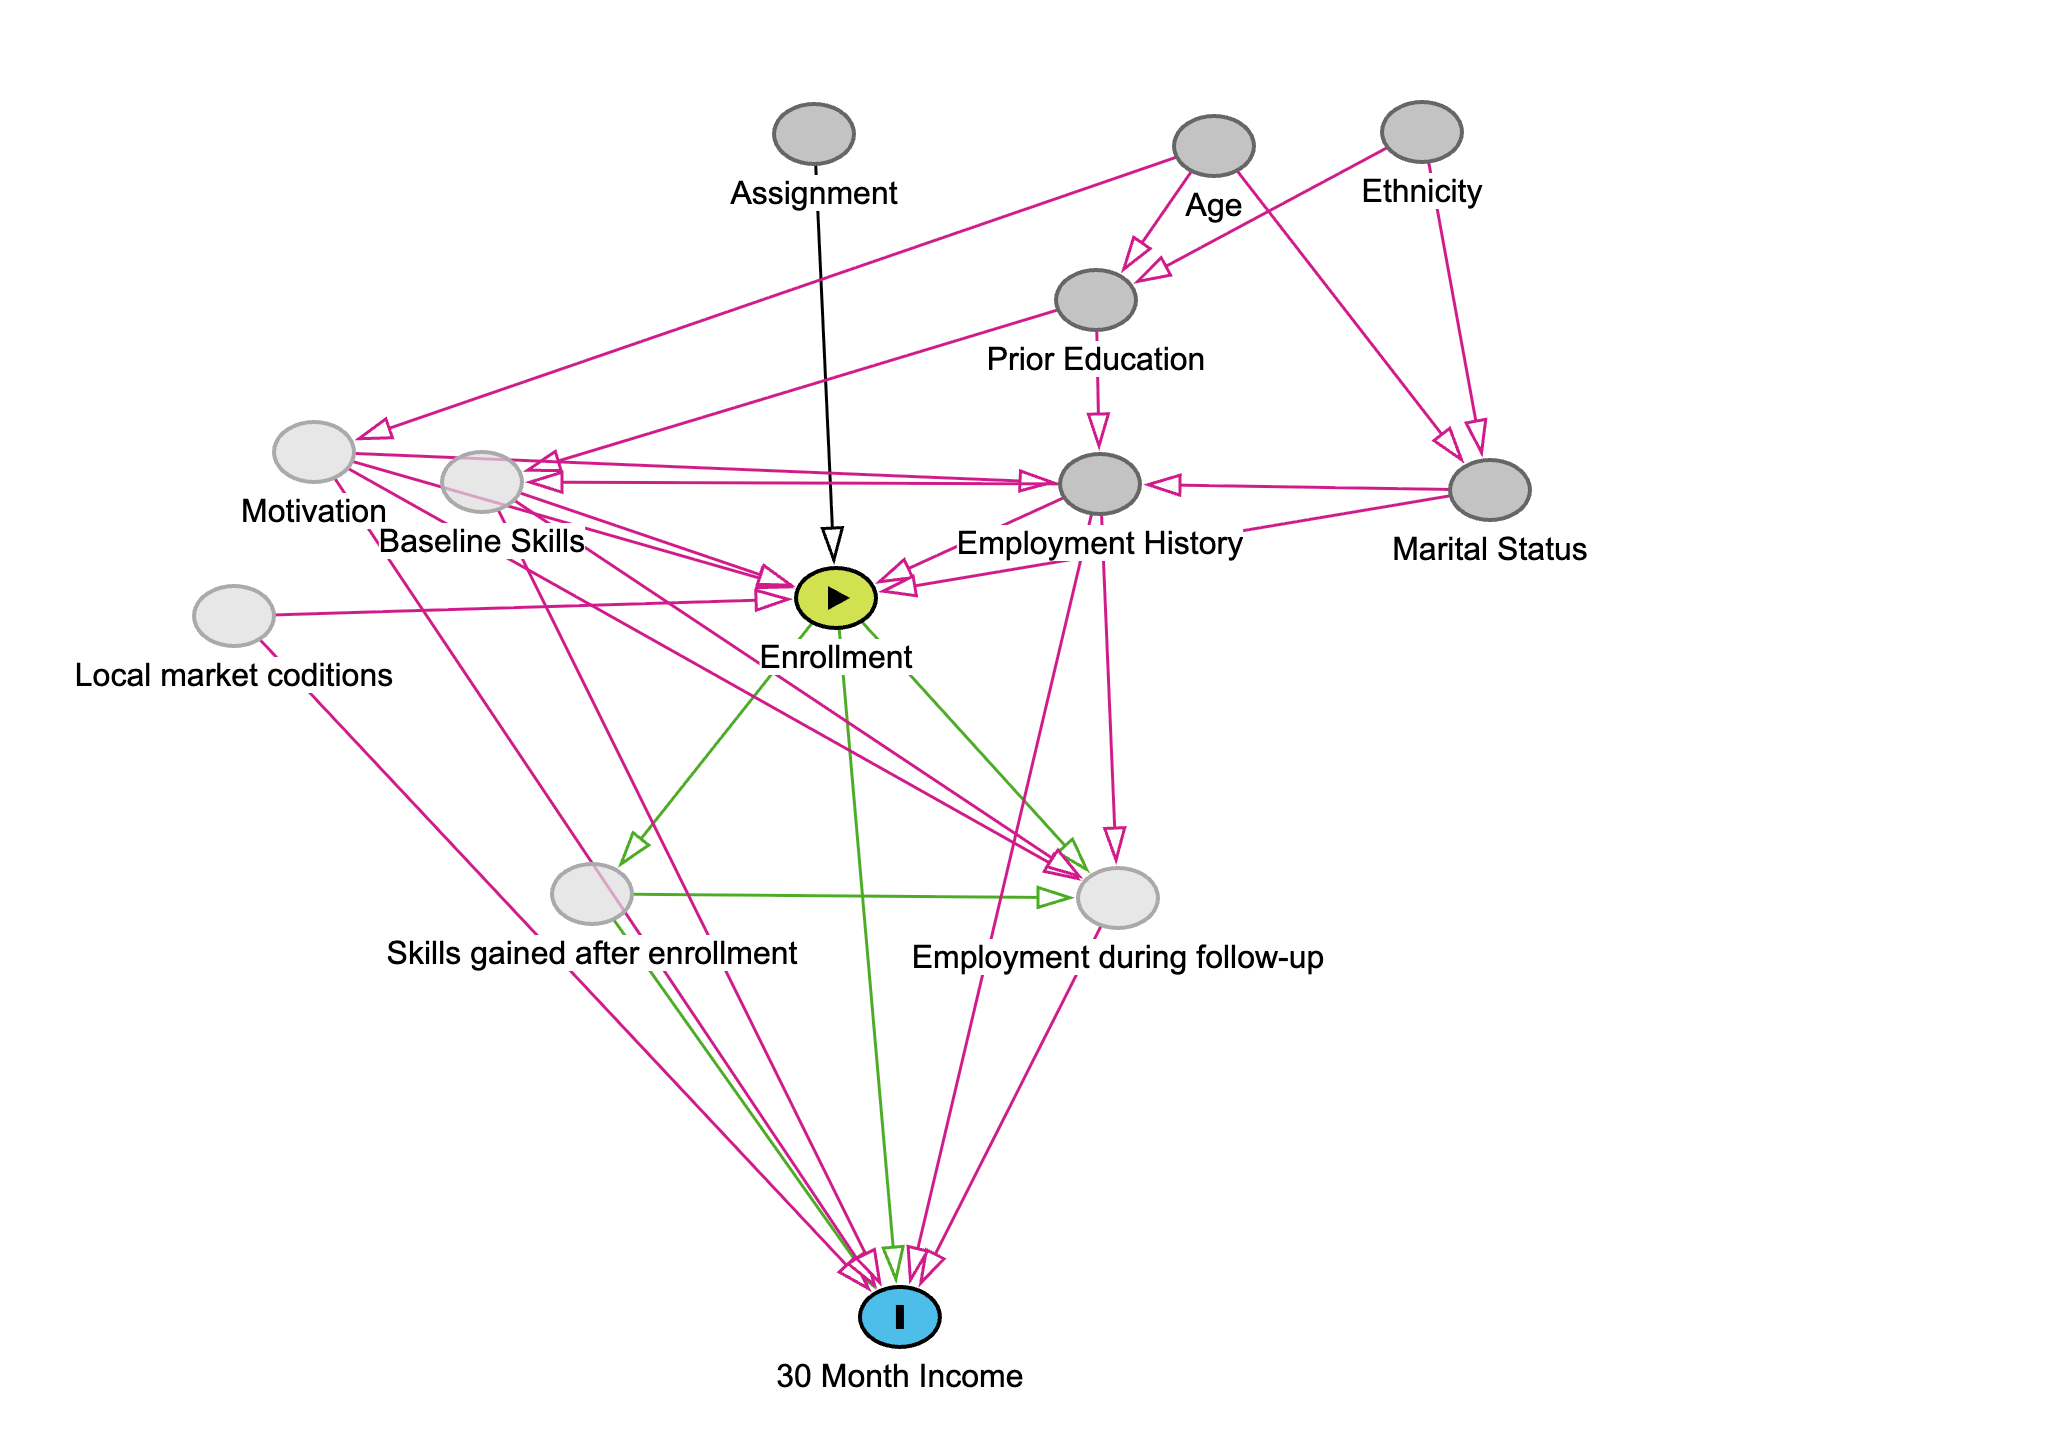

### One-line justification for each arrow

| Arrow | Proposed causal mechanism |
| --- | --- |
| Assignment → Enrollment | Being offered access to JTPA services makes enrollment more likely. |
| Age → Motivation | Life stage can change career priorities and willingness to invest in training. |
| Age → Prior Education | Older cohorts may have had more access to education |
| Age → Marital Status | Older cohorts may be more likely to marry |
| Ethnicity → Prior Education | Sentiment around education may differ across ethnicities, leading to different levels of achievement |
| Ethnicity → Marital Status | Sentiment around marriage may differ across ethnicities, leading to different marriage rates |
| Prior Education → Baseline Skills | Schooling may develop skills already present before assignment|
| Prior Education → Employment History | Educational credentials may affect job access |
| Marital Status → Employment History | Married individuals may be less likely to work |
| Marital Status → Enrollment | Marrital status may affect ability to enroll, possibly through avenues like family status |
| Motivation → Employment History | Motivated individuals may be more likley to have found and retained employment |
| Motivation → Enrollment | Willingness to invest effort in career development may influence desire to participate in training |
| Motivation → Employment during follow-up | Motivation may influence job search regardless of enrollment |
| Motivation → 30 Month Income | Effort and ambition may affect raises/pay |
| Employment History → Baseline Skills | Prior work experience may help develops skills |
| Employment History → Enrollment | Previous work experience may influence one's percieved need for aditional training|
| Employment History → Employment during follow-up | Prior experience and an existing network may influence future employment|
| Employment History → 30 Month Income | Experience or previous titles may affect salary directly when being hired |
| Baseline Skills → Enrollment | Existing skills may affect readiness for training and its perceived benefits |
| Baseline Skills → Employment during follow-up | Existing abilities may affect hiring and job retention independently of training |
| Baseline Skills → 30 Month Income | Existing skills may raise productivity and pay among people who obtain jobs |
| Local market conditions → Enrollment | Available job opportunities can change the attractiveness of working immediately versus entering training |
| Local market conditions → 30 Month Income | Labor demand and prevailing wages may affect subsequent earnings independently of enrollment |
| Enrollment → Skills gained after enrollment | Participation in classes may build new skills|
| Enrollment → Employment during follow-up | Program referrals and job-search assistance may help participants find work. |
| Enrollment → 30 Month Income | Program support such as wage-negotiation guidance could affect pay through routes not captured by new skills or employment status |
| Skills gained after enrollment → Employment during follow-up | New skills may improve eligibility for jobs and the ability to keep them |
| Skills gained after enrollment → 30 Month Income | New skills may improve productivity and wages beyond their effect on obtaining a job|
| Employment during follow-up → 30 Month Income | Obtaining and maintaining paid employment contributes to cumulative earnings during follow-up |

**Implication for the analysis:** Notice how unobserved motivation, baseline skills, and local market conditions (among other unboserved covariates) leave enrollment confounded even after adjusting for measured baseline factors. Skills gained and employment during follow-up are mediators, so we will not adjust for them when estimating the total enrollment effect.


### The main issue -- enrollment is confounded by seen and unseen covariates

Regressing income onto enrollment would leave many observed and unobserved confounding paths, leading to bias in our estimate.  Even if we controlled for our observed confounders, such as age, marital status, and prior employment, unobserved confounders such as motivation and labor-markets would still leave our estimate uninterpretable.  

### The solutions

Because we cannot decouple enrollment from our confounders, we will use assignment as an instrument.  Because assignment is random, it is uncorrelated with any of our observed or unobserved covariates.  Thus, we can use it as a proxy for enrollment while closing off the biasing paths.

### Main control set

We will use age bands, prior education, marital status, prior employment, race/ethnicity indicators, sex, AFDC receipt, and the recommended service strategy (classroom training, and on-the-job training / job-search assistance). The service-strategy recommendation and AFDC status were recorded at intake, before random assignment, so they are baseline characteristics rather than consequences of the offer.  We omit post-enrollment mediators, since adjusting for them would block part of the effect we want to measure, and the survey-source flag (`f2sms`), which is determined after assignment and could introduce selection bias.

In [ ]:
# Define each control once; use its categorical coding in the formula if needed.
age_columns = ["age2225", "age2629", "age3035", "age3644", "age4554"]
categorical_controls = list(status_specs)
control_columns = (
    age_columns
    + categorical_controls
    + [
        "black",
        "hispanic",
        "male",
        "afdc",
        "class_tr",
        "ojt_jsa",
    ]
)
baseline_controls = [
    f"C({name})" if name in categorical_controls else name for name in control_columns
]
control_terms = " + ".join(baseline_controls)
print("Baseline controls:", ", ".join(control_columns))

Baseline controls: age2225, age2629, age3035, age3644, age4554, married, hsorged, prior_employment_status, black, hispanic, male, afdc, class_tr, ojt_jsa


## 5. Enrollment compliance and IV assumptions

### Assignment vs Enrollment

In order to establish a strong connection between assignment and enrollment, we can divide our population into four categories...

1. Assigned and enrolled
2. Assigned and unenrolled
3. Unassigned and enrolled
4. Unassigned and unenrolled

In [9]:
# Z is assignment to an offer; T is actual enrollment.
# Keep all four combinations, even if a group has zero observations.
population_order = pd.MultiIndex.from_tuples(
    [(1, 1), (1, 0), (0, 1), (0, 0)], names=[Z, T]
)
population_counts = df.groupby([Z, T]).size().reindex(population_order, fill_value=0)

four_populations = pd.DataFrame(
    {
        "Population": [
            "Assigned and enrolled",
            "Assigned and unenrolled",
            "Unassigned and enrolled",
            "Unassigned and unenrolled",
        ],
        "Assigned (Z)": population_order.get_level_values(Z),
        "Enrolled (T)": population_order.get_level_values(T),
        "Count": population_counts.to_numpy(),
    }
)
four_populations["Share of sample"] = four_populations["Count"] / len(df)

# Divide each row by the total with the same assignment status.
# For enrolled rows, this is the enrollment rate within that assignment group.
assignment_totals = four_populations.groupby("Assigned (Z)")["Count"].transform("sum")
four_populations["Share within assignment group"] = (
    four_populations["Count"] / assignment_totals
)

print(f"Total sample: {len(df):,} people")
display(
    four_populations.style.hide(axis="index").format(
        {
            "Count": "{:,.0f}",
            "Share of sample": "{:.2%}",
            "Share within assignment group": "{:.2%}",
        }
    )
)

Total sample: 11,204 people


Population,Assigned (Z),Enrolled (T),Count,Share of sample,Share within assignment group
Assigned and enrolled,1,1,"4,804",42.88%,64.16%
Assigned and unenrolled,1,0,"2,683",23.95%,35.84%
Unassigned and enrolled,0,1,54,0.48%,1.45%
Unassigned and unenrolled,0,0,"3,663",32.69%,98.55%


We can see that we have fairly strong compliance within the assigned population -- around 64%.  Additionally, we have extremely strong compliance within the unassigned population -- 98.55%.  

Now, we can indroduce some population classifiers as follows:

1. Compliers -- these people will do as they are assigned
2. Never Takers -- these people will never take the course, regardless of assignment
3. Always takers -- these people will always take the course, regardless of assignment
4. Defiers -- these people will do the opposite of what they are assigned

In practice, defiers are rare and often ignored in studies like these. By ignoring defiers, our assigned and unenrolled and unassigned and enrolled become pure proxies for never takers and always takers, allowing us to compute compliers cleanly.

1. Compliers: 62.71%
2. Never Takers: 35.84%
3. Always takers: 1.45%
4. Defiers: 0%

### Validate Instrument assumptions

With the effect of assignment on enrollment established, we now propose using assignment as an instrument to estimate the causal effect of enrolling.  We need to establish 3 core IV conditions, plus monotonicity for the actual interpretation of our effect.

1. Relevance: Assignment must change the probability of enrollment -- confirmed via the data above
2. Independence: Assignment is independent of preexisiting covariates that may affect income or enrollment -- supported by balanced covariate groups above and via experimental design description
3. Exclusion: Assignment only affects earning through enrollment -- Receiving an offer to take a course would not intrinsically change job search, skills, etc...  We can argue for this by noting the recommendations preceeded assignment, so assignment really only affected access to services, not knowledge of services.
4. Monotonicity -- i.e. we don't have defiers.  It's hard to make an argument that receiving an offer would make someone NOT want to take the class, while not receiving an offer would.  Further, our small proportion of always takers (1.45%) provides a tight cap on the overall population of defiers, if they exist.

## 6. Assignment effect and enrollment association -- establishing baselines

Its useful to have a baseline for our estimated treament effect by using a couple of naive regressions.  We will use HC1 standard errors, allowing for unequal variance in the outcome across groups.

In [10]:
# Fix one common sample before fitting any model; keep the same people throughout.
model_sample = df[[Y, T, Z, *control_columns]].dropna().copy()
print(f"Common model sample: {len(model_sample):,} of {len(df):,} people")
model_sample.to_csv(PROCESSED_DIR / "jtpa_model_sample.csv", index=False)


def model_result(model, parameter, estimand):
    """Extract the same reporting fields from statsmodels OLS or linearmodels IV."""
    ci = model.conf_int().loc[parameter]
    se = model.std_errors if hasattr(model, "std_errors") else model.bse
    return {
        "Estimand": estimand,
        "Estimate ($)": model.params[parameter],
        "Robust SE ($)": se[parameter],
        "95% CI lower ($)": ci.iloc[0],
        "95% CI upper ($)": ci.iloc[1],
        "p-value": model.pvalues[parameter],
        "N": int(model.nobs),
    }

Common model sample: 11,204 of 11,204 people


### Assignment effect (ITT)

In [11]:
# The randomized-offer coefficient is the intention-to-treat effect.
naive_assignment_model = smf.ols(f"{Y} ~ {Z}", data=model_sample).fit(
    cov_type="HC1", use_t=True
)
display(naive_assignment_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          earnings_30mo   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     12.31
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           0.000452
Time:                        15:10:25   Log-Likelihood:            -1.2487e+05
No. Observations:               11204   AIC:                         2.498e+05
Df Residuals:                   11202   BIC:                         2.498e+05
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.504e+04    265.381     56.675      0.000    1.45e+04    1.56e+04
offer       1159.4333    330.463      3.509      0.000     511.669    1807.198
==============================================================================
Omnibus:                     3334.936   Durbin-Watson:                   2.005
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10118.335
Skew:                           1.544   Prob(JB):                         0.00
Kurtosis:                       6.485   Cond. No.                         3.23
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

We see that if we regress assignment against earnings, those assigned to the course earn on average $1,159.43 more than those who are unassigned, with a statistically significant result.  This is a causal relationship due to randomization, but this estimate likely understates the impact of the course, as only 64% of those assigned to the course actually end up taking it.  It answers the question about whether assignment affects income, but we are interested about actual enrollment.

### Unadjusted enrollment association

In [12]:
# This enrollment association can reflect selection as well as a treatment effect.
naive_enrollment_model = smf.ols(f"{Y} ~ {T}", data=model_sample).fit(
    cov_type="HC1", use_t=True
)
display(naive_enrollment_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          earnings_30mo   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     76.12
Date:                Tue, 15 Sep 2026   Prob (F-statistic):           3.04e-18
Time:                        15:10:25   Log-Likelihood:            -1.2484e+05
No. Observations:               11204   AIC:                         2.497e+05
Df Residuals:                   11202   BIC:                         2.497e+05
Df Model:                           1                                         
Covariance Type:                  HC1                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   1.461e+04    206.879     70.597      0.000    1.42e+04     1.5e+04
enrolled    2791.0875    319.900      8.725      0.000    2164.028    3418.147
==============================================================================
Omnibus:                     3370.834   Durbin-Watson:                   2.004
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            10395.538
Skew:                           1.554   Prob(JB):                         0.00
Kurtosis:                       6.551   Cond. No.                         2.49
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC1)
"""

By regressing the enrolled population vs the outcome, we get a much larger effect size of 2,791.09.  This estimate, however, likely overstates the causal effect, as we now have confounding paths due to removing our random assignment assumption.  One potential confounder would be motivation to succeed -- those who are already motivated may be more likely to enroll AND more likely to earn more.  Therefore, motivation will affect both the treatment and the outcome positively, leading to us attributing income increases due to motivation directly to enrollment instead (since motivation is not in our regression).  This is just one hypothesized confounder -- the key idea is that we now have bias in our estimated becasue of the existance of unmeasured or unknown factors that both influence enrollment and income.

## 7. Instrumental-variable estimates

### Uncontrolled IV

We instrument actual enrollment (`enrolled`) with randomized assignment (`offer`), including an intercept and no covariate controls. With a binary instrument, this 2SLS coefficient equals the Wald estimate:

$$
\widehat{\tau}_{IV}
= \frac{E_n[Y\mid Z=1]-E_n[Y\mid Z=0]}
       {E_n[T\mid Z=1]-E_n[T\mid Z=0]}.
$$

The denominator is the **difference** in enrollment rates: approximately 64.16% − 1.45% = **62.71 percentage points**, rather than just the assigned group's enrollment rate. Under relevance, independence, exclusion, and monotonicity (with a well-defined treatment and no interference), this estimates the average enrollment effect for **compliers**, not necessarily the effect for every participant.

Conceptually, we first predict enrollment from assignment, then uses that predicted enrollment to explain earnings. This is simply scaling our estimate from regressing income on assignment by the difference in assigned people who enrolled and unassigned people who enrolled.  

We use `IV2SLS` to compute the estimate and its covariance together: since ordinary OLS standard errors from a manually fitted second stage are inappropriate.

We request `cov_type="robust", debiased=True`: heteroskedasticity-robust IV standard errors with an HC1-style $n/(n-k)$ correction and t-based confidence intervals. These account for estimation through the instrument and allow unequal error variances, assuming independent observations. “Debiased” refers to the covariance adjustment; it does not guarantee a consistent causal estimate or validate the instrument. See the [IV2SLS fitting documentation](https://bashtage.github.io/linearmodels/iv/iv/linearmodels.iv.model.IV2SLS.fit.html).


In [13]:
# No covariate controls; robust IV covariance with an HC1-style correction.
uncontrolled_iv_model = IV2SLS.from_formula(
    f"{Y} ~ 1 + [{T} ~ {Z}]", data=model_sample
).fit(cov_type="robust", debiased=True)
display(uncontrolled_iv_model.summary)

# With one binary instrument, 2SLS must equal the Wald ratio on the same sample.
group_means = model_sample.groupby(Z)[[Y, T]].mean()
itt = group_means.loc[1, Y] - group_means.loc[0, Y]
first_stage = group_means.loc[1, T] - group_means.loc[0, T]
wald = itt / first_stage
np.testing.assert_allclose(uncontrolled_iv_model.params[T], wald)
print(f"Wald check: ${itt:,.2f} / {first_stage:.5f} = ${wald:,.2f}")
print(
    f"Assignment changes enrollment by {first_stage:.2%} ({100 * first_stage:.2f} percentage points)."
)

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:          earnings_30mo   R-squared:                      0.0060
Estimator:                    IV-2SLS   Adj. R-squared:                 0.0059
No. Observations:               11204   F-statistic:                    12.338
Date:                Tue, Sep 15 2026   P-value (F-stat)                0.0004
Time:                        15:10:25   Distribution:               F(1,11202)
Cov. Estimator:                robust                                         
                                                                              
                             Parameter Estimates                              
==============================================================================
            Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
------------------------------------------------------------------------------
Intercept   1.501e+04     271.63     55.272     0.0000   1.448e+04   1.555e+04
enrolled       1848.8     526.34     3.5126     0.0004      817.10      2880.6
==============================================================================

Endogenous: enrolled
Instruments: offer
Robust Covariance (Heteroskedastic)
Debiased: True
"""

Wald check: $1,159.43 / 0.62712 = $1,848.83
Assignment changes enrollment by 62.71% (62.71 percentage points).


#### Interpreting the IV estimate

It's important to explicitly name the effect we are measuring.  This is the average treatment effect of enrolling in the course for compliers -- people who will enroll if offered, and won't enroll if not. We can't individually identify these compliers, but we recover their effect by dividing the assignment earning difference by the differnce in proportion of people who enrolled after being offered vs those who enrolled after not being offered.

We get an estimate of $1848, with a standard error of 526.344.

### Controlled IV

We can also run the regression with our control set, as they are measured before assignment and plausably relate to both enrollment and income.  The purpose of controlling for these covariates is not to change our estimate of the effect, which was already consistent, but rather to reduce the standard error of that estimate!  This does not mean, however, that the estimate will not change.

In [14]:
# Exogenous controls enter both stages automatically; assignment instruments enrollment.
controlled_iv_model = IV2SLS.from_formula(
    f"{Y} ~ 1 + {control_terms} + [{T} ~ {Z}]", data=model_sample
).fit(cov_type="robust", debiased=True)
display(controlled_iv_model.summary)

<class 'linearmodels.compat.statsmodels.Summary'>
"""
                          IV-2SLS Estimation Summary                          
==============================================================================
Dep. Variable:          earnings_30mo   R-squared:                      0.1119
Estimator:                    IV-2SLS   Adj. R-squared:                 0.1105
No. Observations:               11204   F-statistic:                    70.320
Date:                Tue, Sep 15 2026   P-value (F-stat)                0.0000
Time:                        15:10:25   Distribution:              F(18,11185)
Cov. Estimator:                robust                                         
                                                                              
                                                           Parameter Estimates                                                           
=========================================================================================================================================
                                                                       Parameter  Std. Err.     T-stat    P-value    Lower CI    Upper CI
-----------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                 9813.2     812.91     12.072     0.0000      8219.7   1.141e+04
age2225                                                                   3918.8     733.24     5.3445     0.0000      2481.6      5356.1
age2629                                                                   4580.4     745.51     6.1440     0.0000      3119.1      6041.7
age3035                                                                   4352.4     737.96     5.8979     0.0000      2905.9      5799.0
age3644                                                                   3716.4     748.77     4.9633     0.0000      2248.7      5184.2
age4554                                                                   1934.4     814.70     2.3744     0.0176      337.44      3531.4
C(married)[T.Married]                                                     3460.5     392.31     8.8208     0.0000      2691.5      4229.5
C(married)[T.Unknown]                                                    -813.20     532.10    -1.5283     0.1265     -1856.2      229.81
C(hsorged)[T.Diploma/GED]                                                 3604.5     327.23     11.015     0.0000      2963.1      4245.9
C(hsorged)[T.Unknown]                                                     3389.5     662.46     5.1165     0.0000      2090.9      4688.0
C(prior_employment_status)[T.Worked less than 13 weeks in prior year]    -6356.7     328.51    -19.350     0.0000     -7000.6     -5712.7
C(prior_employment_status)[T.Unknown]                                    -4636.7     475.83    -9.7444     0.0000     -5569.4     -3704.0
black                                                                    -1196.2     358.52    -3.3365     0.0009     -1899.0     -493.45
hispanic                                                                 -414.85     470.17    -0.8823     0.3776     -1336.5      506.77
male                                                                      4079.3     328.67     12.411     0.0000      3435.0      4723.5
afdc                                                                     -1957.9     361.82    -5.4112     0.0000     -2667.1     -1248.7
class_tr                                                                 -1529.0     398.71    -3.8350     0.0001     -2310.6     -747.50
ojt_jsa                                                                   953.80     387.23     2.4632     0.0138      194.77      1712.8
enrolled                                                                  1770.9     497.66     3.5584     0.0004      795.38      2746.4
=============================================================

After adding our control set, we get an effect size of $1771 and slightly smaller SE of $498.  Note the change in effect size does not reveal bias in our uncontrolled regression -- with a valid instrument, our uncontrolled regression is a consistent estimate as well.

### Comparing the estimates

All four models use the same people. The assignment effect, enrollment association, and IV complier effects answer different questions, with the IV complier effect getting the closest to answering the question guiding this notebook.

In [15]:
model_comparison = pd.DataFrame.from_dict(
    {
        "Assignment OLS": model_result(naive_assignment_model, Z, "Offer effect (ITT)"),
        "Enrollment OLS": model_result(
            naive_enrollment_model, T, "Enrollment association"
        ),
        "Uncontrolled IV": model_result(
            uncontrolled_iv_model, T, "Enrollment effect for compliers*"
        ),
        "Controlled IV": model_result(
            controlled_iv_model, T, "Enrollment effect for compliers*"
        ),
    },
    orient="index",
)
model_comparison.index.name = "Model"
model_comparison.insert(
    1,
    "Interpretation",
    pd.Series(
        {
            "Assignment OLS": "Causal",
            "Enrollment OLS": "Non-causal",
            "Uncontrolled IV": "Causal under IV assumptions",
            "Controlled IV": "Causal under IV assumptions",
        }
    ),
)
dollar_columns = [name for name in model_comparison if "($)" in name]
display(
    model_comparison.style.format(
        {
            **{name: "${:,.2f}" for name in dollar_columns},
            "p-value": lambda p: "<0.001" if p < 0.001 else f"{p:.3f}",
            "N": "{:,.0f}",
        }
    )
)
print(
    "* Causal interpretation requires the IV assumptions; controls do not establish them."
)
model_comparison.to_csv(TABLES_DIR / "model_comparison.csv")

first_stage_diagnostics = pd.concat(
    {
        "Uncontrolled IV": uncontrolled_iv_model.first_stage.diagnostics,
        "Controlled IV": controlled_iv_model.first_stage.diagnostics,
    }
)[["partial.rsquared", "f.stat", "f.dist"]]
print(
    "First-stage diagnostics: robust f.stat is a Wald chi-square, not the outcome-model F-statistic."
)
display(first_stage_diagnostics.round(3))
first_stage_diagnostics.to_csv(TABLES_DIR / "first_stage_diagnostics.csv")

,Estimand,Interpretation,Estimate ($),Robust SE ($),95% CI lower ($),95% CI upper ($),p-value,N
Model,,,,,,,,
Assignment OLS,Offer effect (ITT),Causal,"$1,159.43",$330.46,$511.67,"$1,807.20",<0.001,"11,204"
Enrollment OLS,Enrollment association,Non-causal,"$2,791.09",$319.90,"$2,164.03","$3,418.15",<0.001,"11,204"
Uncontrolled IV,Enrollment effect for compliers*,Causal under IV assumptions,"$1,848.83",$526.34,$817.10,"$2,880.56",<0.001,"11,204"
Controlled IV,Enrollment effect for compliers*,Causal under IV assumptions,"$1,770.87",$497.66,$795.38,"$2,746.37",<0.001,"11,204"


* Causal interpretation requires the IV assumptions; controls do not establish them.
First-stage diagnostics: robust f.stat is a Wald chi-square, not the outcome-model F-statistic.


,,partial.rsquared,f.stat,f.dist
Uncontrolled IV,enrolled,0.355,11376.464,chi2(1)
Controlled IV,enrolled,0.361,11296.548,chi2(1)


## 8. Conclusion

The controlled or uncontrolled IV both get the closest to answering our guiding question: "How does enrolling in JTPA services impact total earnings?"  Since there is no reason not to control for the covariates measured before assignment, and doing so reducess the standard error of our estimate, I will report the controlled IV estimate as our final number.

Enrolling in JTPA services increases 30 month income by a total of $1771, with a standard error of $498. The 95% confidence interval of this estimate runs from $795 to $2746, and the point estimate for the total income over 30 months is $15041, meaning this estimate represents an 11.7% increase in income.

Note that this increase is the average effect for compliers only, i.e. the 62.7% of adults who enroll in JTPA services only when offered a spot.  It does not say anything about the 35.8% who never enroll or the 1.5% who always enroll.  

## 9. Limitations

The primary limitation in this study is the IV assumptions.   Specifically, exclusion is only argued for and not proven, and it is possible taht control-group members could get similar training elsewhere. Additionally, 30 months is a short time horizon, and it's possible that hte effect on earnings was short lived/temporary, not maintained.  If this is the case, longer studies would report smaller and smaller effect sizes.  

## 10. Next steps

The natural question that follows these finding is if the $1770 number actually exceeds the cost per enrollee.  That cost would have to include both any straight up costs for the training and the cost of lost time, i.e. if the course takes away time from either a job search or a preexisting job.  

